In [20]:
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str # 공제액 
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산
    
graph_builder = StateGraph(AgentState)

# data imbedding


In [22]:
# from langchain_text_splitters import RecursiveCharacterTextSplitter

# text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200,separators=['\n\n','\n'])


In [23]:
# from langchain_community.document_loaders import TextLoader

# txt_path = "./documents/real_estate_tax.txt"

# loader = TextLoader(txt_path)
# document_list = loader.load_and_split(text_splitter)

In [24]:
# from langchain_chroma import Chroma
# from langchain_openai import OpenAIEmbeddings

# embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')
# vectorstore = Chroma.from_documents(
#     documents=document_list,
#     embedding=embedding_function,
#     collection_name="real_estate_tax",
#     persist_directory="./real_estate_tax_collection"
# )

In [25]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [26]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [27]:
from langchain_openai import ChatOpenAI
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

client = Client()
rag_prompt  = client.pull_prompt("rlm/rag-prompt")
llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [28]:
tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    |StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(query: str) -> AgentState :
    tax_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 알려주세요'
    tax_base_equation = tax_base_chain.invoke(tax_equation_question)
    return {'tax_base_equation' : tax_base_equation}

In [29]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | rag_prompt 
    | llm 
    | StrOutputParser()
)
def get_tax_deduction(query: str) -> AgentState:
    tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction' : tax_deduction}

In [30]:
from langchain_tavily import TavilySearch
from datetime import date

tavily_search_tool = TavilySearch(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True
    )

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state:AgentState) :
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    context = tavily_search_tool.invoke(query)
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | llm
        | StrOutputParser()
    )
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    return {'market_ratio': market_ratio}

In [31]:
from langchain_core.prompts import PromptTemplate

tax_base_calculation_prompt = PromptTemplate.from_template("""
주어진 내용을 기반으로 과세표준을 계산해주세요

과세표준 계산공식: {tax_base_equation}
공제금액 : {tax_deduction}
공정시장가액비율: {market_ratio}
사용자 주택 공시가격 정보: {query}                                                        
""")

def calculate_tax_base(state: AgentState) -> AgentState:
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    tax_base_calculation_chain = (
        tax_base_calculation_prompt
        | llm
        | StrOutputParser()
    )
    tax_base = tax_base_calculation_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })
    return {'tax_base': tax_base}

In [32]:
tax_rate_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', '''당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요

종합부동산세 세율:{context}'''),
    ('human', '''과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요

과세표준: {tax_base}
주택 수:{query}''')
])

def calculate_tax_rate(state: AgentState) -> AgentState: 
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    
    tax_rate_chain = (
        tax_rate_calculation_prompt
        | llm
        | StrOutputParser()
    )
    
    tax_rate = tax_rate_chain.invoke({
        'context': context, 
        'tax_base': tax_base, 
        'query': query
    })

    return {'answer': tax_rate}

In [33]:
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

In [34]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')
graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')
graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [35]:
graph = graph_builder.compile()

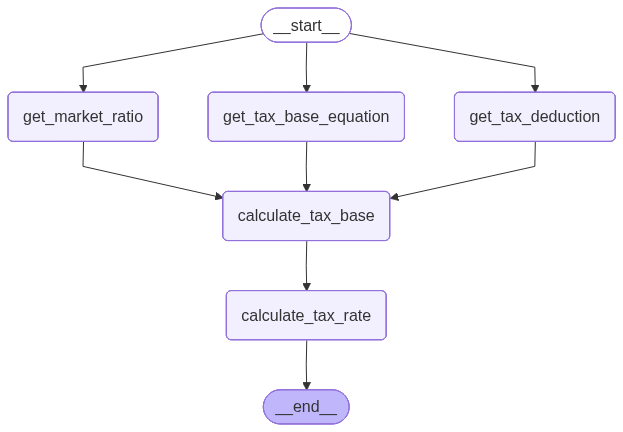

In [36]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
initial_state = {'query': query}
graph.invoke(initial_state)

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주어진 조건에 따라 사용자는 총 3채의 주택을 소유하고 있으므로, "3주택 이상을 소유한 경우"의 종합부동산세율을 적용받게 됩니다.\n\n과세표준은 15.6억 원으로 계산되었습니다. 이에 대해 3주택 이상 소유자의 세율을 적용하여 종합부동산세를 계산하면 다음과 같습니다:\n\n과세표준이 12억 원 초과 25억 원 이하에 해당하므로, 해당 구간의 세율을 사용합니다:\n- 960만 원 + (12억 원을 초과하는 금액의 1천분의 20)\n\n따라서 세액은 다음과 같습니다:\n- 초과금액 = 15.6억 - 12억 = 3.6억 원\n- 세액 = 960만 원 + (3.6억 원 × 0.002) = 960만 원 + 720만 원 = 1,680만 원\n\n사용자는 1,680만 원의 종합부동산세를 납부해야 합니다.',
 'tax_base_equation': '과세표준 = max(0, (공시가격의 합 - 공제 금액)) × 공정시장가액비율',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시 공제금액은 1세대 1주택자의 경우 12억 원, 법인 또는 법인으로 보는 단체는 6억 원, 그 외의 경우에는 9억 원입니다.',
 'market_ratio': '2026년 1월 30일 현재, 주택 공시가격에 대한 공정시장가액비율은 60%입니다.',
 'tax_base': '주어진 정보를 바탕으로 과세표준을 계산해 보겠습니다.\n\n1. **공시가격의 합 계산:**\n   - 5억 원짜리 집 1채\n   - 10억 원짜리 집 1채\n   - 20억 원짜리 집 1채\n\n   공시가격의 합 = 5억 + 10억 + 20억 = 35억 원\n\n2. **공제금액 적용:**\n   - 주어진 정보로 보아 주택 소유자의 유형은 명확하지 않으므로 일반적인 경우(다주택자 및 1세대 1주택자가 아닌 경우)로 가정하여 공제금액은 9억 원으로 하겠습니다.\